# EDA: Multi-Pollutant Air Quality Estimation

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
DATA_PATH = Path("../data/AirQualityUCI.csv")

df = pd.read_csv(DATA_PATH, sep=";", decimal=",", na_values=-200)
df = df.drop(columns=['Unnamed: 15', 'Unnamed: 16']).dropna(how='all')
df['DateTime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'].str.replace('.', ':'),
    format='%d/%m/%Y %H:%M:%S')
df = df.drop(columns=['Date', 'Time'])


In [3]:
df.head()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,DateTime
0,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,2004-03-10 18:00:00
1,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,2004-03-10 19:00:00
2,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,2004-03-10 20:00:00
3,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,2004-03-10 21:00:00
4,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,2004-03-10 22:00:00


In [45]:
print(f"Number of rows: {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]:,}")
print(f"Data period: {df['DateTime'].min()} - {df['DateTime'].max()}")
print(f"Invalid DateTime values: {df['DateTime'].isna().sum():,}")

Number of rows: 9,357
Number of columns: 21
Data period: 2004-03-10 18:00:00 - 2005-04-04 14:00:00
Invalid DateTime values: 0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   CO(GT)         7674 non-null   float64       
 1   PT08.S1(CO)    8991 non-null   float64       
 2   NMHC(GT)       914 non-null    float64       
 3   C6H6(GT)       8991 non-null   float64       
 4   PT08.S2(NMHC)  8991 non-null   float64       
 5   NOx(GT)        7718 non-null   float64       
 6   PT08.S3(NOx)   8991 non-null   float64       
 7   NO2(GT)        7715 non-null   float64       
 8   PT08.S4(NO2)   8991 non-null   float64       
 9   PT08.S5(O3)    8991 non-null   float64       
 10  T              8991 non-null   float64       
 11  RH             8991 non-null   float64       
 12  AH             8991 non-null   float64       
 13  DateTime       9357 non-null   datetime64[us]
dtypes: datetime64[us](1), float64(13)
memory usage: 1023.6 KB


In [6]:
df.dtypes

CO(GT)                  float64
PT08.S1(CO)             float64
NMHC(GT)                float64
C6H6(GT)                float64
PT08.S2(NMHC)           float64
NOx(GT)                 float64
PT08.S3(NOx)            float64
NO2(GT)                 float64
PT08.S4(NO2)            float64
PT08.S5(O3)             float64
T                       float64
RH                      float64
AH                      float64
DateTime         datetime64[us]
dtype: object

In [7]:
df.sample(5, random_state=42)

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,DateTime
2973,1.3,933.0,NaN,6.4,831.0,105.0,888.0,72.0,1514.0,710.0,26.0,34.9,1.1509,2004-07-12 15:00:00
3396,NaN,894.0,NaN,4.9,761.0,36.0,862.0,48.0,1504.0,768.0,23.0,49.9,1.3849,2004-07-30 06:00:00
4372,2.6,1226.0,NaN,14.6,1138.0,307.0,862.0,146.0,1481.0,1419.0,25.1,32.3,1.0131,2004-09-08 22:00:00
6025,3.1,1101.0,NaN,14.5,1134.0,427.0,683.0,168.0,1283.0,1281.0,13.6,34.0,0.5251,2004-11-16 19:00:00
7960,1.3,966.0,NaN,4.9,760.0,302.0,877.0,200.0,890.0,940.0,7.5,39.2,0.4091,2005-02-05 10:00:00


In [8]:
df.describe()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,DateTime
count,7674.000000,8991.000000,914.000000,8991.000000,8991.000000,7718.000000,8991.000000,7715.000000,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000,9357
mean,2.152750,1099.833166,218.811816,10.083105,939.153376,246.896735,835.493605,113.091251,1456.264598,1022.906128,18.317829,49.234201,1.025530,2004-09-21 16:00:00
min,0.100000,647.000000,7.000000,0.100000,383.000000,2.000000,322.000000,2.000000,551.000000,221.000000,-1.900000,9.200000,0.184700,2004-03-10 18:00:00
25%,1.100000,937.000000,67.000000,4.400000,734.500000,98.000000,658.000000,78.000000,1227.000000,731.500000,11.800000,35.800000,0.736800,2004-06-16 05:00:00
50%,1.800000,1063.000000,150.000000,8.200000,909.000000,180.000000,806.000000,109.000000,1463.000000,963.000000,17.800000,49.600000,0.995400,2004-09-21 16:00:00
75%,2.900000,1231.000000,297.000000,14.000000,1116.000000,326.000000,969.500000,142.000000,1674.000000,1273.500000,24.400000,62.500000,1.313700,2004-12-28 03:00:00
max,11.900000,2040.000000,1189.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000,2005-04-04 14:00:00
std,1.453252,217.080037,204.459921,7.449820,266.831429,212.979168,256.817320,48.370108,346.206794,398.484288,8.832116,17.316892,0.403813,NaN


In [46]:
target_columns = [
    "CO(GT)",
    "C6H6(GT)",
    "NOx(GT)",
    "NO2(GT)",
]

sensor_features = [
    "PT08.S1(CO)",
    "PT08.S2(NMHC)",
    "PT08.S3(NOx)",
    "PT08.S4(NO2)",
    "PT08.S5(O3)",
]

environment_features = ["T", "RH", "AH"]

print("Target columns:", target_columns)
print("Sensor features:", sensor_features)
print("Environment features:", environment_features)

Target columns: ['CO(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)']
Sensor features: ['PT08.S1(CO)', 'PT08.S2(NMHC)', 'PT08.S3(NOx)', 'PT08.S4(NO2)', 'PT08.S5(O3)']
Environment features: ['T', 'RH', 'AH']


In [47]:
analysis_columns = (sensor_features + environment_features + target_columns + ["NMHC(GT)"])

missing_summary = (
    df[analysis_columns].isna().agg(["sum", "mean"]).T.rename(columns={
        "sum": "missing_count",
        "mean": "missing_ratio"
    })
)

missing_summary["missing_percent"] = (missing_summary["missing_ratio"] * 100)

missing_summary = missing_summary.sort_values(
    "missing_percent",
    ascending=False
)

missing_summary

,missing_count,missing_ratio,missing_percent
NMHC(GT),8443.0,0.902319,90.231912
CO(GT),1683.0,0.179865,17.986534
NO2(GT),1642.0,0.175484,17.548360
NOx(GT),1639.0,0.175163,17.516298
PT08.S1(CO),366.0,0.039115,3.911510
PT08.S5(O3),366.0,0.039115,3.911510
PT08.S4(NO2),366.0,0.039115,3.911510
PT08.S3(NOx),366.0,0.039115,3.911510
PT08.S2(NMHC),366.0,0.039115,3.911510
AH,366.0,0.039115,3.911510


In [48]:
target_availability = pd.DataFrame({
    "available_count": df[target_columns].notna().sum(),
    "missing_count": df[target_columns].isna().sum(),
    "available_percent": df[target_columns].notna().mean().mul(100),
    "missing_percent": df[target_columns].isna().mean().mul(100),
})

target_availability

,available_count,missing_count,available_percent,missing_percent
CO(GT),7674,1683,82.013466,17.986534
C6H6(GT),8991,366,96.088490,3.911510
NOx(GT),7718,1639,82.483702,17.516298
NO2(GT),7715,1642,82.451640,17.548360


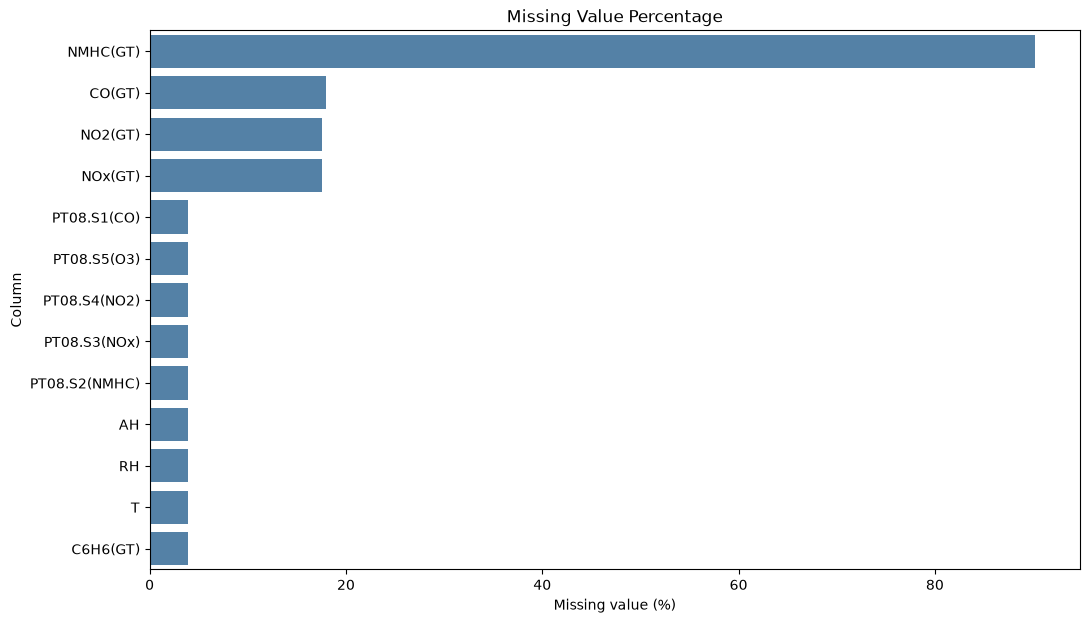

In [49]:
missing_plot = (missing_summary.reset_index().rename(columns={"index": "column"}))

plt.figure(figsize=(12, 7))

sns.barplot(
    data=missing_plot,
    x="missing_percent",
    y="column",
    color="steelblue"
)

plt.title("Missing Value Percentage")
plt.xlabel("Missing value (%)")
plt.ylabel("Column")
plt.show()

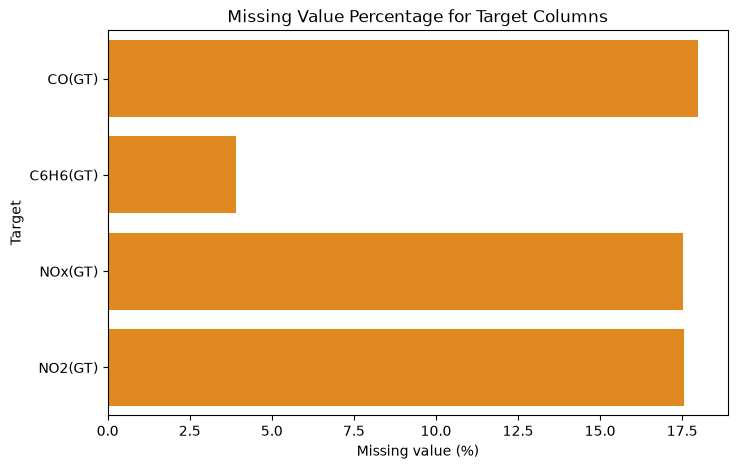

In [50]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=target_availability.reset_index(),
    x="missing_percent",
    y="index",
    color="darkorange"
)

plt.title("Missing Value Percentage for Target Columns")
plt.xlabel("Missing value (%)")
plt.ylabel("Target")
plt.show()

In [12]:
print("Number of duplicates:", df.duplicated().sum())
print("Number of empty DateTime:", df["DateTime"].isna().sum())
print("Number of duplicate DateTime:", df["DateTime"].duplicated().sum())
print("Sorted data:", df["DateTime"].is_monotonic_increasing)

Number of duplicates: 0
Number of empty DateTime: 0
Number of duplicate DateTime: 0
Sorted data: True


In [13]:
time_gap = df["DateTime"].diff().value_counts().head(10)
time_gap

DateTime
0 days 01:00:00    9356
Name: count, dtype: int64

In [51]:
target_observations = {}

for target in target_columns:
    target_df = df.dropna(subset=[target]).copy()
    target_observations[target] = target_df

    print(f"\nTarget: {target}")
    print(f"Available observations: {len(target_df):,}")
    print(f"Missing observations: {df[target].isna().sum():,}")
    print(f"Available percentage: {df[target].notna().mean() * 100:.2f}%")

target_statistics = df[target_columns].describe().T
target_statistics


Target: CO(GT)
Available observations: 7,674
Missing observations: 1,683
Available percentage: 82.01%

Target: C6H6(GT)
Available observations: 8,991
Missing observations: 366
Available percentage: 96.09%

Target: NOx(GT)
Available observations: 7,718
Missing observations: 1,639
Available percentage: 82.48%

Target: NO2(GT)
Available observations: 7,715
Missing observations: 1,642
Available percentage: 82.45%


,count,mean,std,min,25%,50%,75%,max
CO(GT),7674.0,2.152750,1.453252,0.1,1.1,1.8,2.9,11.9
C6H6(GT),8991.0,10.083105,7.449820,0.1,4.4,8.2,14.0,63.7
NOx(GT),7718.0,246.896735,212.979168,2.0,98.0,180.0,326.0,1479.0
NO2(GT),7715.0,113.091251,48.370108,2.0,78.0,109.0,142.0,340.0


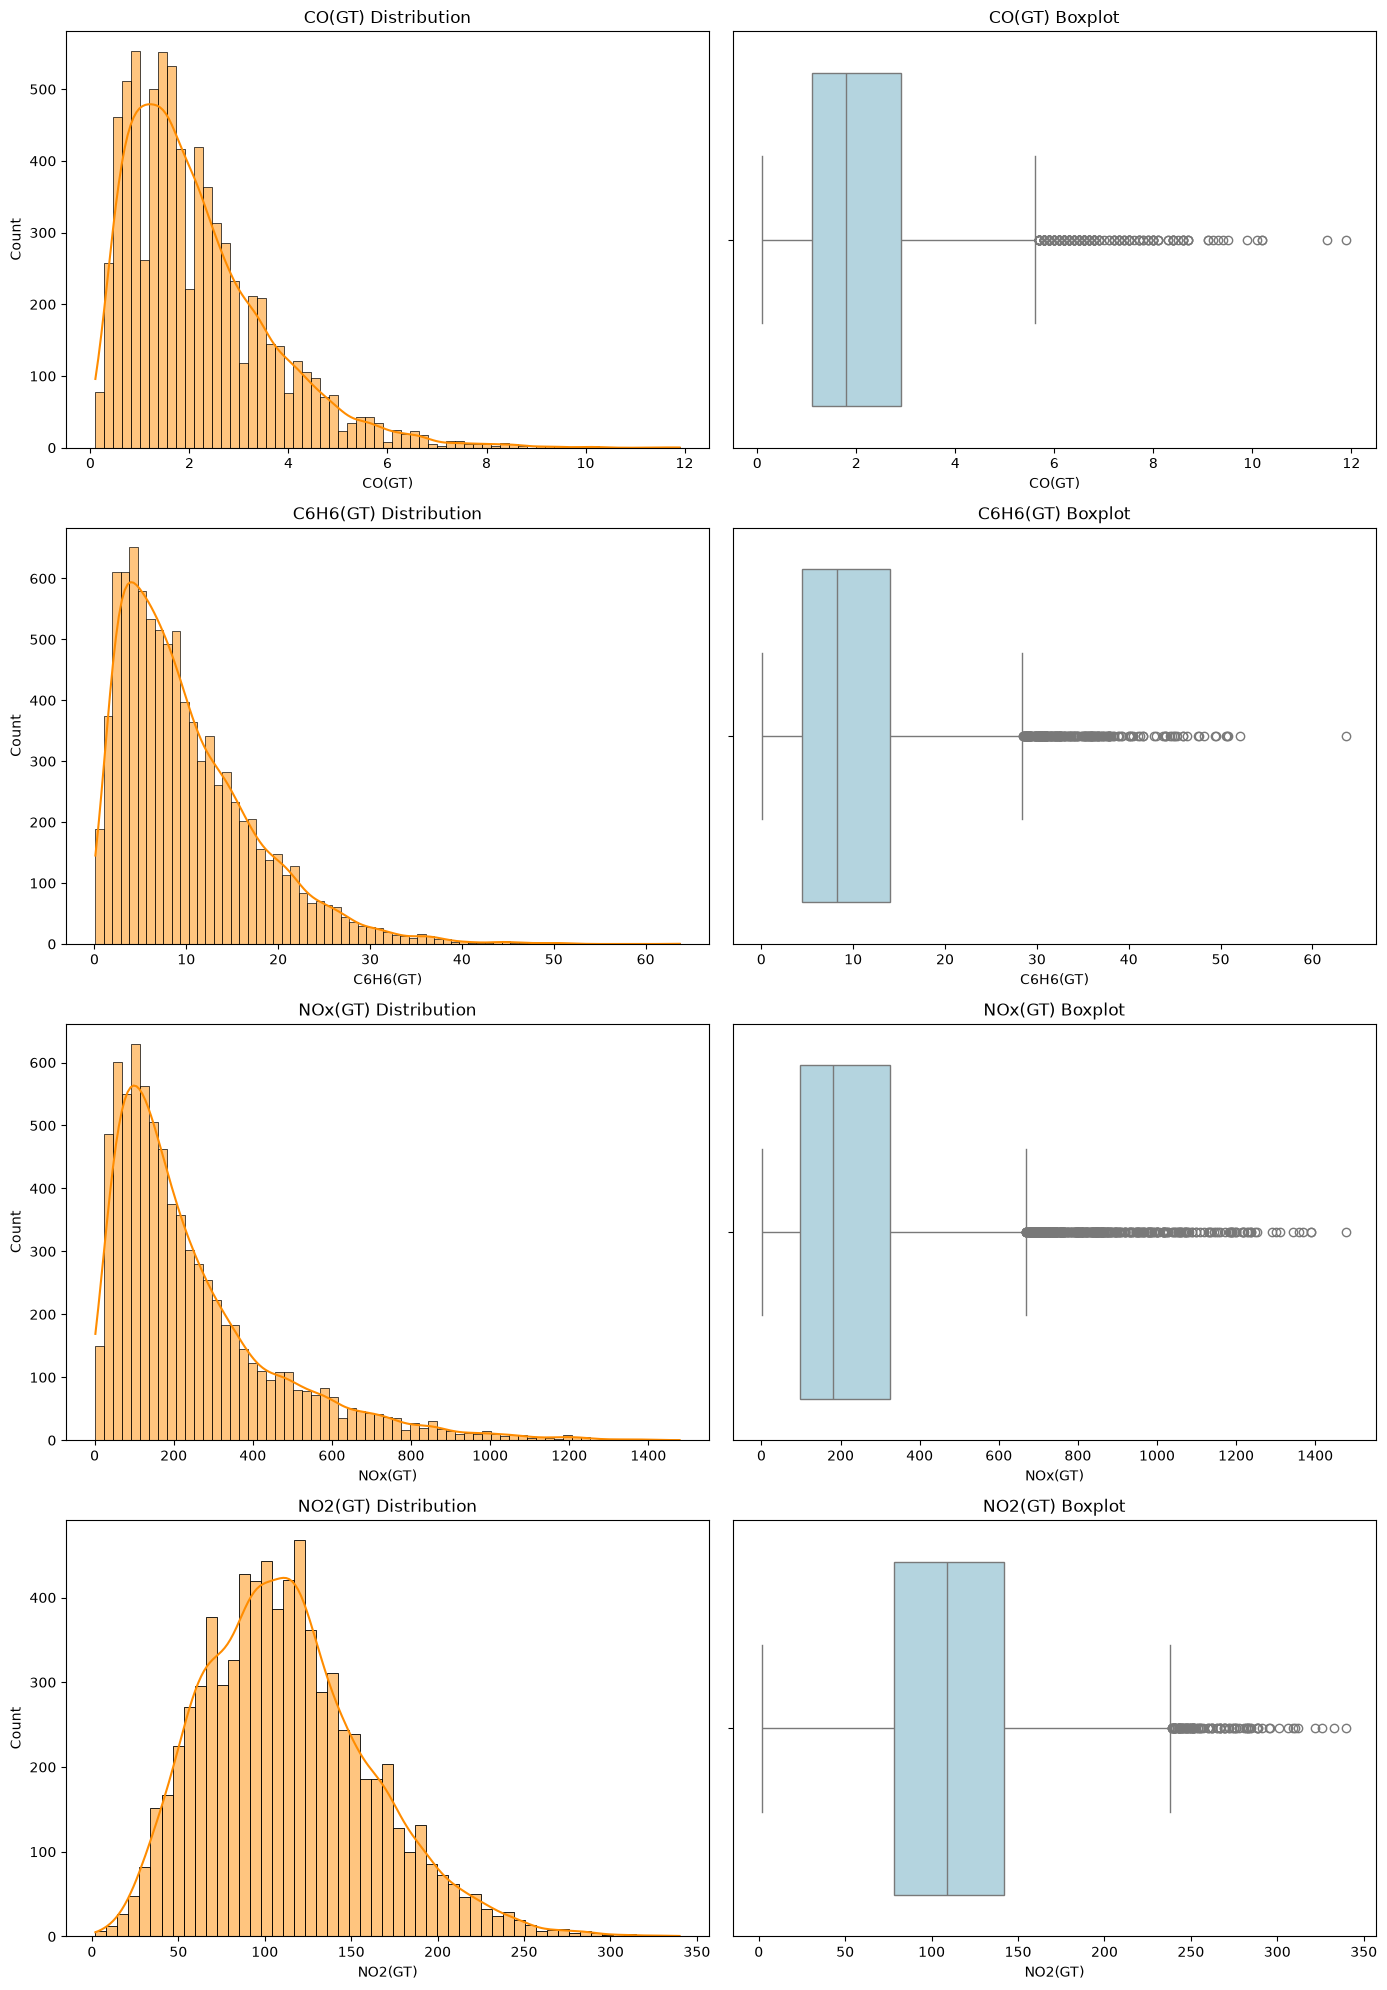

In [52]:
fig, axes = plt.subplots(len(target_columns), 2, figsize=(14, 5 * len(target_columns)))

for row, target in enumerate(target_columns):
    target_df = df.dropna(subset=[target])

    sns.histplot(
        data=target_df,
        x=target,
        kde=True,
        ax=axes[row, 0],
        color="darkorange"
    )

    axes[row, 0].set_title(f"{target} Distribution")
    axes[row, 0].set_xlabel(target)

    sns.boxplot(
        data=target_df,
        x=target,
        ax=axes[row, 1],
        color="lightblue"
    )

    axes[row, 1].set_title(f"{target} Boxplot")
    axes[row, 1].set_xlabel(target)

plt.tight_layout()
plt.show()

In [53]:
target_distribution_summary = pd.DataFrame({
    "missing_percent": df[target_columns].isna().mean() * 100,
    "count": df[target_columns].count(),
    "min": df[target_columns].min(),
    "max": df[target_columns].max(),
    "mean": df[target_columns].mean(),
    "median": df[target_columns].median(),
    "std": df[target_columns].std(),
    "skewness": df[target_columns].skew(),
    "kurtosis": df[target_columns].kurtosis(),
})

target_distribution_summary

,missing_percent,count,min,max,mean,median,std,skewness,kurtosis
CO(GT),17.986534,7674,0.1,11.9,2.152750,1.8,1.453252,1.369753,2.667779
C6H6(GT),3.911510,8991,0.1,63.7,10.083105,8.2,7.449820,1.361532,2.488706
NOx(GT),17.516298,7718,2.0,1479.0,246.896735,180.0,212.979168,1.715781,3.402134
NO2(GT),17.548360,7715,2.0,340.0,113.091251,109.0,48.370108,0.621714,0.465032


In [55]:
df["year"] = df["DateTime"].dt.year
df["month"] = df["DateTime"].dt.month
df["day"] = df["DateTime"].dt.day
df["day_of_week"] = df["DateTime"].dt.dayofweek
df["hour"] = df["DateTime"].dt.hour
df["is_weekend"] = df["day_of_week"] >= 5
df["day_name"] = df["DateTime"].dt.day_name()

time_features = [
    "hour",
    "day_of_week",
    "month",
    "is_weekend"
]

feature_columns = (sensor_features + environment_features + time_features)
analysis_columns = (feature_columns + target_columns + ["NMHC(GT)"])

df[["DateTime"] + time_features].head()

,DateTime,hour,day_of_week,month,is_weekend
0,2004-03-10 18:00:00,18,2,3,False
1,2004-03-10 19:00:00,19,2,3,False
2,2004-03-10 20:00:00,20,2,3,False
3,2004-03-10 21:00:00,21,2,3,False
4,2004-03-10 22:00:00,22,2,3,False


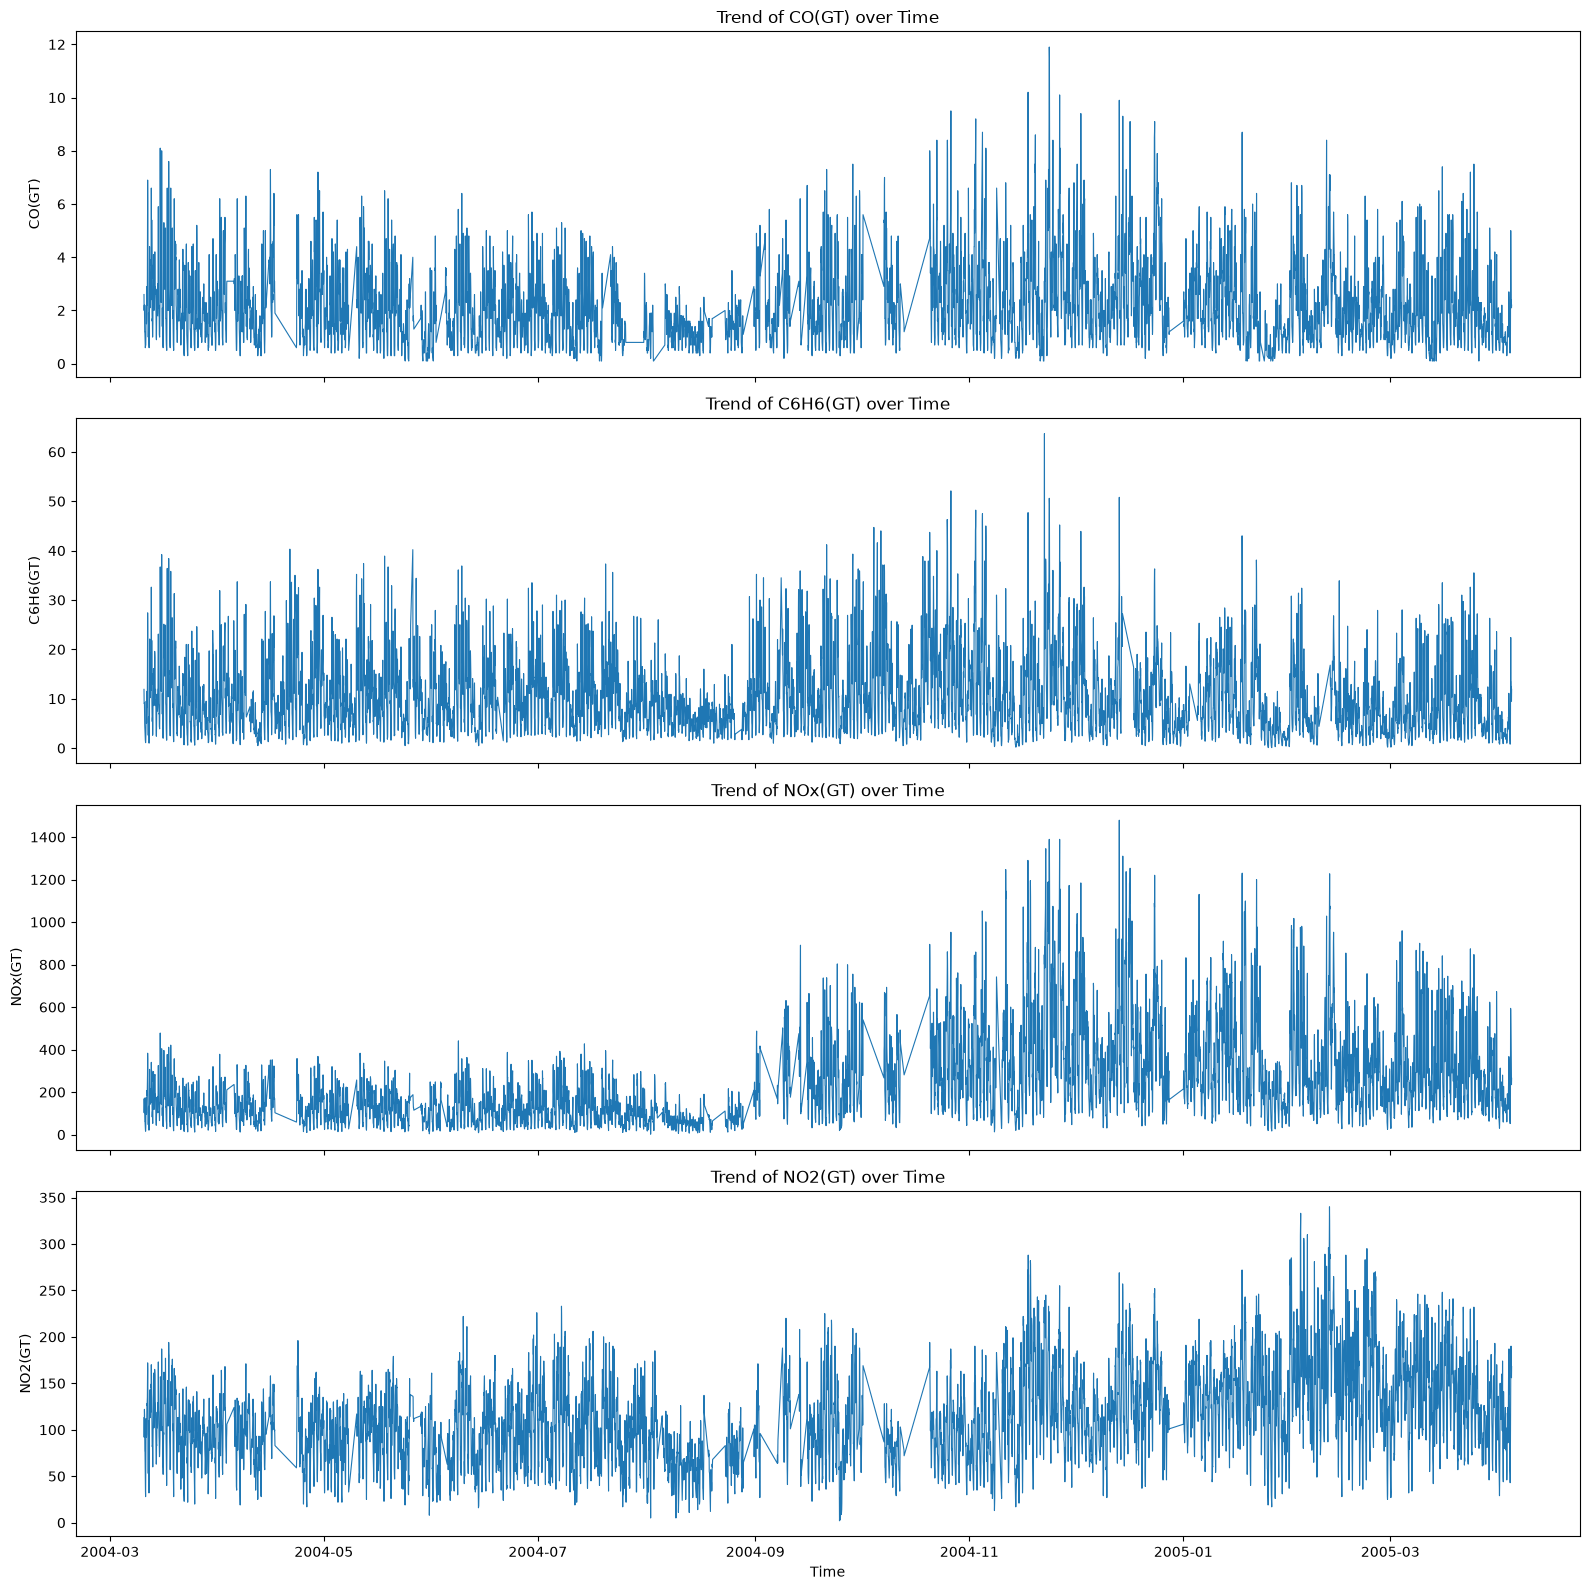

In [56]:
fig, axes = plt.subplots(len(target_columns), 1, figsize=(16, 4 * len(target_columns)), sharex=True)

for ax, target in zip(axes, target_columns):
    target_df = df.dropna(subset=[target])

    sns.lineplot(
        data=target_df,
        x="DateTime",
        y=target,
        linewidth=0.8,
        ax=ax
    )

    ax.set_title(f"Trend of {target} over Time")
    ax.set_xlabel("Time")
    ax.set_ylabel(target)

plt.tight_layout()
plt.show()

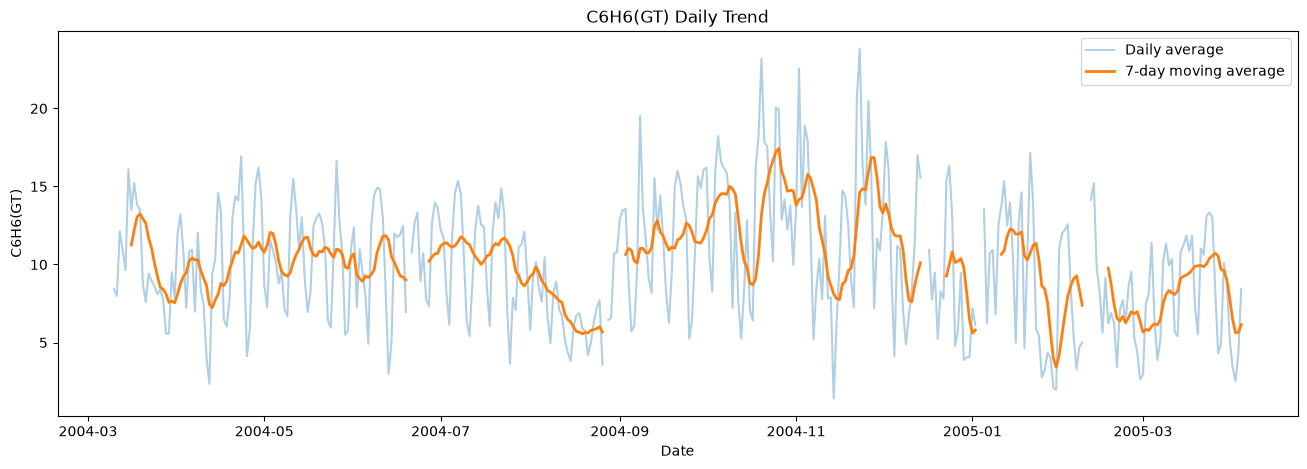

In [19]:
daily_target = (
    target_df
    .set_index("DateTime")[target]
    .resample("D")
    .mean()
)
rolling_target = daily_target.rolling(7).mean()

plt.figure(figsize=(16, 5))
plt.plot(
    daily_target,
    alpha=0.35,
    label="Daily average"
)
plt.plot(
    rolling_target,
    linewidth=2,
    label="7-day moving average"
)
plt.title("C6H6(GT) Daily Trend")
plt.xlabel("Date")
plt.ylabel("C6H6(GT)")
plt.legend()
plt.show()

In [20]:
hourly_target = (
    df
    .groupby("hour")[target]
    .agg(["mean", "median", "std", "count"])
)

hourly_target

,mean,median,std,count
hour,,,,
0,7.684140,7.00,3.921664,372
1,5.991711,5.50,3.170991,374
2,4.379467,3.80,2.561266,375
3,3.379255,2.90,2.228278,376
4,2.916711,2.60,1.991421,377
5,3.068435,2.80,1.935430,377
6,4.756117,4.30,2.768897,376
7,10.398936,7.70,7.823343,376
8,15.894149,15.10,9.829296,376


In [22]:
peak_hour = hourly_target["mean"].idxmax()
peak_value = hourly_target["mean"].max()

print(f"Hour with the highest average: {peak_hour:02d}:00")
print(f"Hour average: {peak_value:.3f}")

Hour with the highest average: 19:00
Hour average: 17.736


In [23]:
minimum_hour = hourly_target["mean"].idxmin()
minimum_value = hourly_target["mean"].min()

print(f"Hour with the lowest average: {minimum_hour:02d}:00")
print(f"Hour average: {minimum_value:.3f}")

Hour with the lowest average: 04:00
Hour average: 2.917


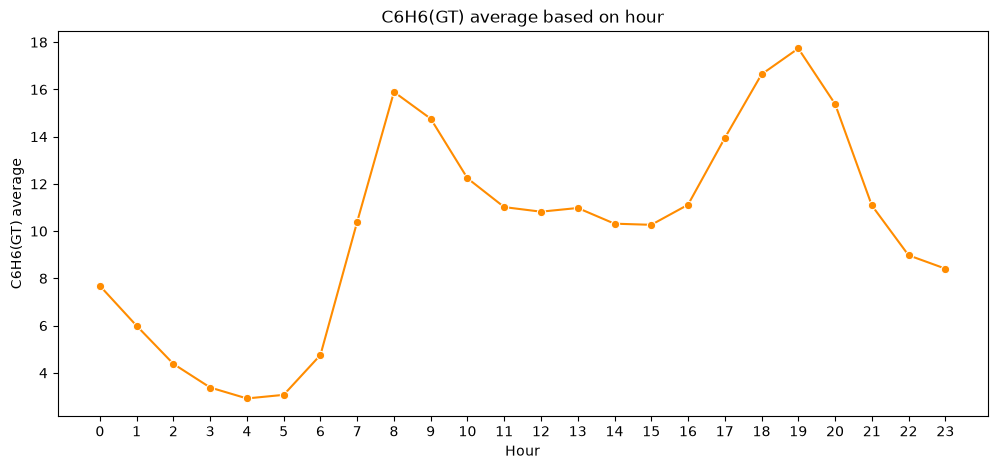

In [24]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=hourly_target,
    x=hourly_target.index,
    y="mean",
    marker="o",
    color="darkorange"
)

plt.title("C6H6(GT) average based on hour")
plt.xlabel("Hour")
plt.ylabel("C6H6(GT) average")
plt.xticks(range(24))
plt.show()

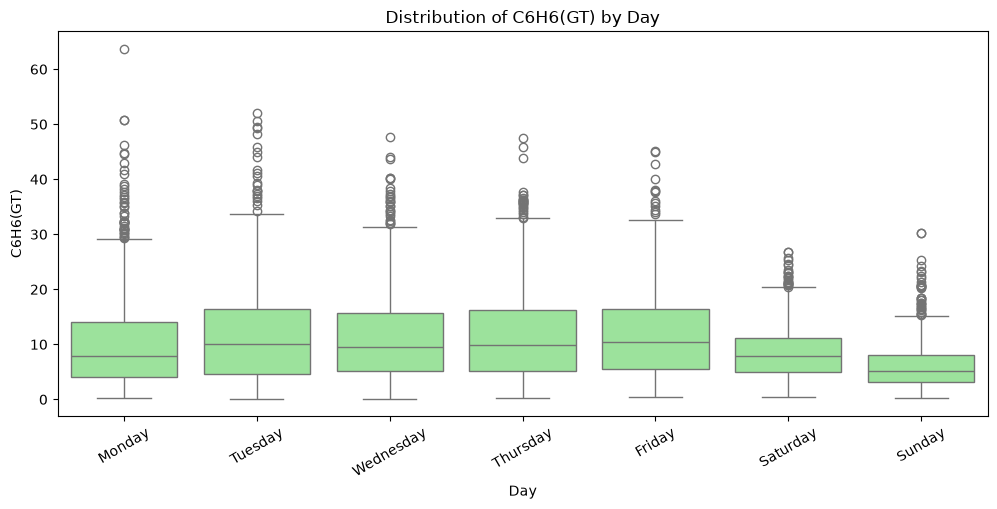

In [25]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

df["day_name"] = df["DateTime"].dt.day_name()

plt.figure(figsize=(12, 5))

sns.boxplot(
    data=df,
    x="day_name",
    y=target,
    order=day_order,
    color="lightgreen"
)

plt.title("Distribution of C6H6(GT) by Day")
plt.xlabel("Day")
plt.ylabel("C6H6(GT)")
plt.xticks(rotation=30)
plt.show()

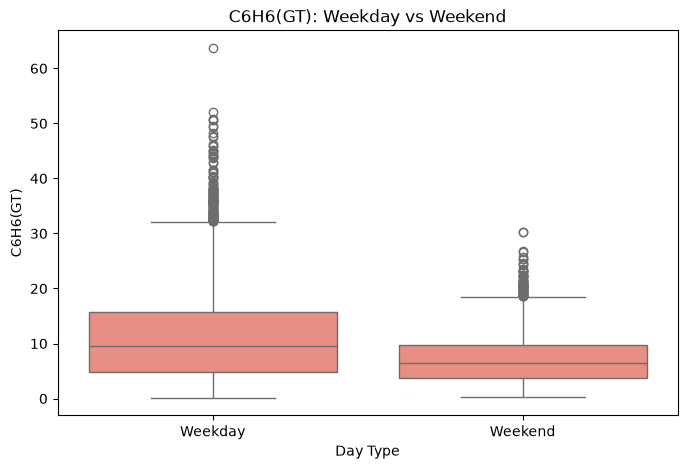

In [26]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="is_weekend",
    y=target,
    color="salmon"
)

plt.title("C6H6(GT): Weekday vs Weekend")
plt.xlabel("Day Type")
plt.ylabel("C6H6(GT)")
plt.xticks([0, 1], ["Weekday", "Weekend"])
plt.show()

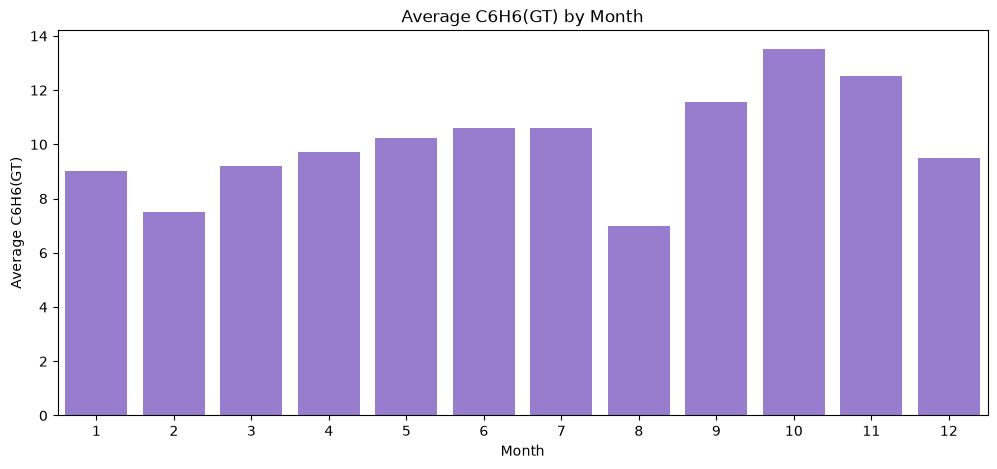

In [27]:
monthly_target = df.groupby("month")[target].mean()

plt.figure(figsize=(12, 5))

sns.barplot(
    x=monthly_target.index,
    y=monthly_target.values,
    color="mediumpurple"
)

plt.title("Average C6H6(GT) by Month")
plt.xlabel("Month")
plt.ylabel("Average C6H6(GT)")
plt.show()

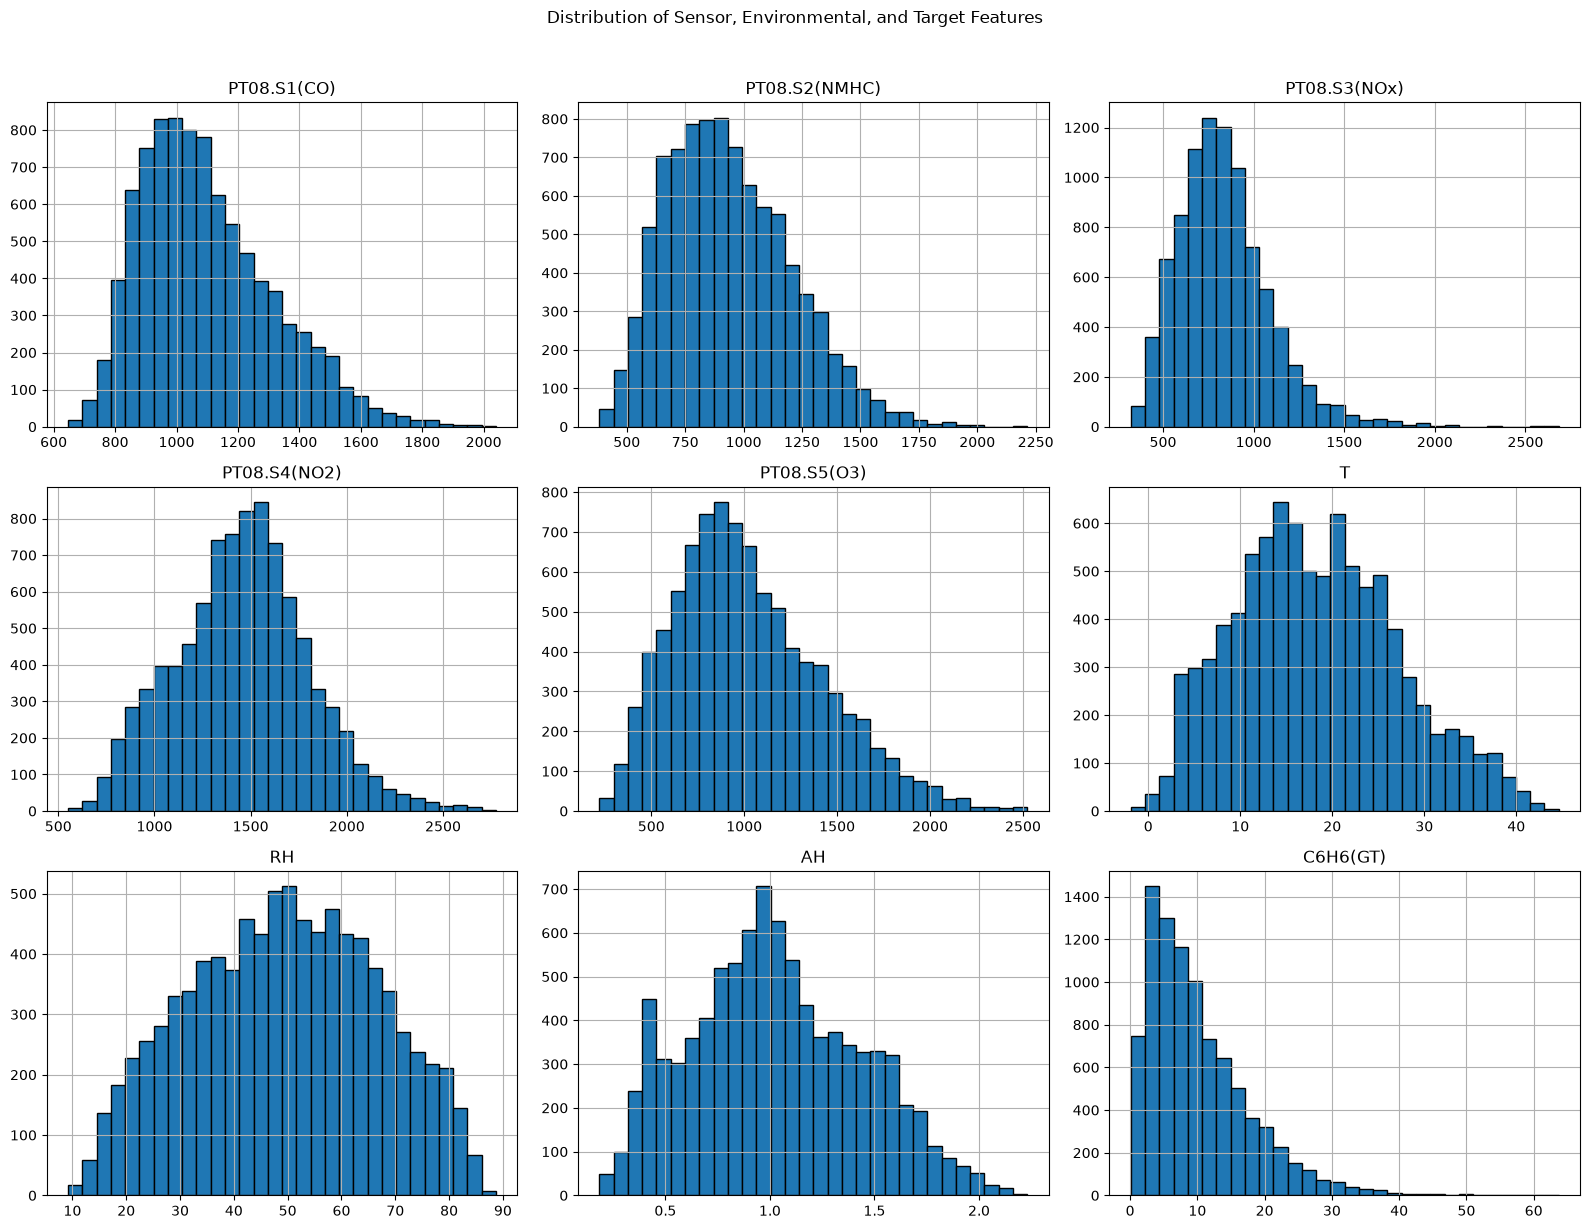

In [28]:
numeric_columns = feature_columns + [target]

df[numeric_columns].hist(
    figsize=(16, 12),
    bins=30,
    edgecolor="black"
)

plt.suptitle("Distribution of Sensor, Environmental, and Target Features", y=1.02)
plt.tight_layout()
plt.show()

In [30]:
pollutant_analysis_columns = other_pollutant_features + [target]
df[pollutant_analysis_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
CO(GT),7674.0,2.152750,1.453252,0.1,1.1,1.8,2.9,11.9
NOx(GT),7718.0,246.896735,212.979168,2.0,98.0,180.0,326.0,1479.0
NO2(GT),7715.0,113.091251,48.370108,2.0,78.0,109.0,142.0,340.0
C6H6(GT),8991.0,10.083105,7.449820,0.1,4.4,8.2,14.0,63.7


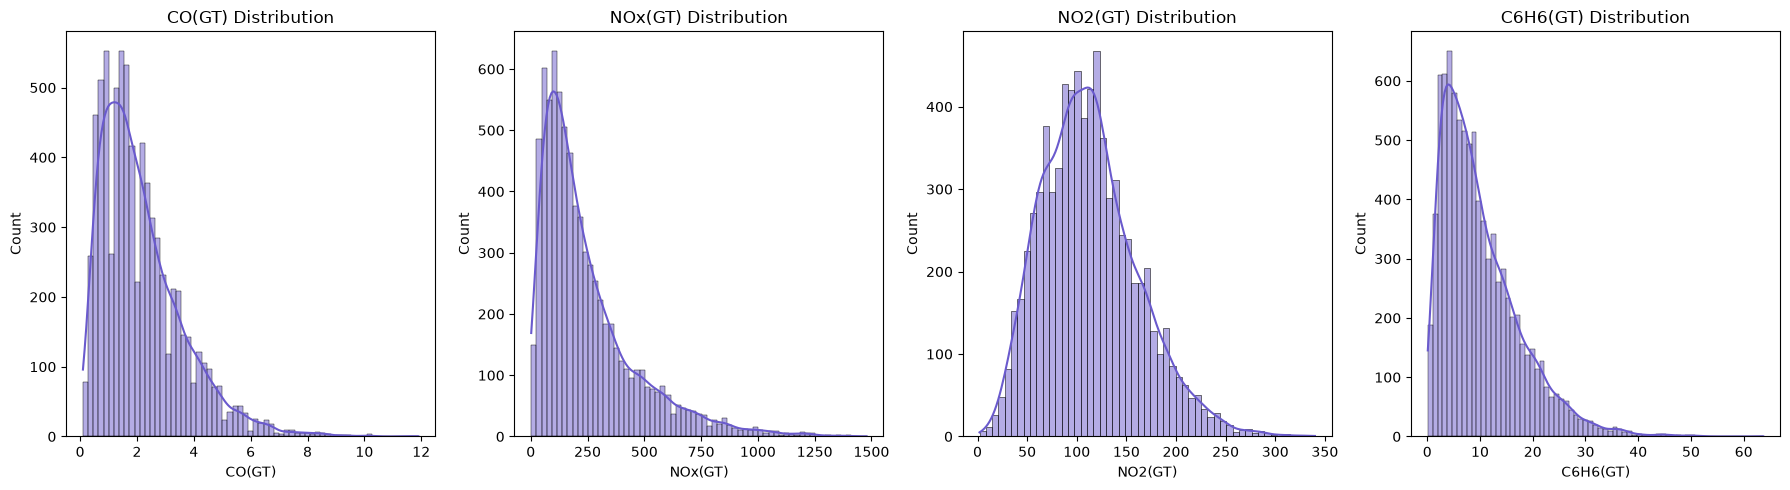

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, column in zip(axes, pollutant_analysis_columns):
    sns.histplot(
        data=df,
        x=column,
        kde=True,
        ax=ax,
        color="slateblue"
    )
    ax.set_title(f"{column} Distribution")

plt.tight_layout()
plt.show()

In [38]:
distribution_summary = pd.DataFrame({
    "missing_percent": df[pollutant_analysis_columns].isna().mean() * 100,
    "skewness": df[pollutant_analysis_columns].skew(),
    "kurtosis": df[pollutant_analysis_columns].kurtosis(),
    "mean": df[pollutant_analysis_columns].mean(),
    "median": df[pollutant_analysis_columns].median()
})

distribution_summary

,missing_percent,skewness,kurtosis,mean,median
CO(GT),17.986534,1.369753,2.667779,2.152750,1.8
NOx(GT),17.516298,1.715781,3.402134,246.896735,180.0
NO2(GT),17.548360,0.621714,0.465032,113.091251,109.0
C6H6(GT),3.911510,1.361532,2.488706,10.083105,8.2


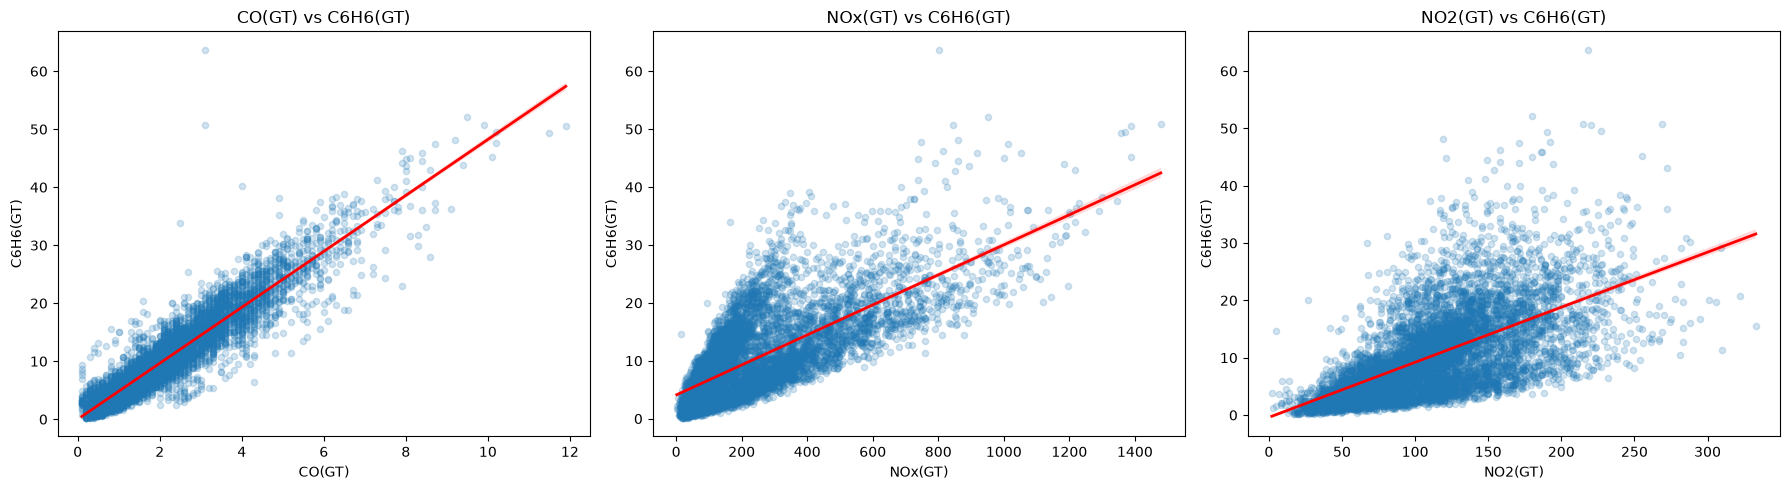

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, column in zip(axes, other_pollutant_features):
    sns.regplot(
        data=df,
        x=column,
        y=target,
        scatter_kws={
            "alpha": 0.2,
            "s": 20
        },
        line_kws={
            "color": "red",
            "linewidth": 2
        },
        ax=ax
    )

    ax.set_title(f"{column} vs {target}")

plt.tight_layout()
plt.show()